В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [35]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [36]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [106]:
cars_df.Price.min()

450000

In [37]:
# Числові колонки
cars_df.select_dtypes(include='number').columns

Index(['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power',
       'Seats', 'Price'],
      dtype='object')

In [38]:
cars_df.select_dtypes(include='number').columns.shape

(8,)

In [39]:
# Категоріальні колонки
cat_cols = cars_df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {cars_df[col].nunique()} унікальних значень {cars_df[col].unique()}')
    print()
print(cat_cols.shape)

Brand: 11 унікальних значень ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

Model: 58 унікальних значень ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

Fuel_Type: 2 унікальних значень ['Petrol' 'Diesel']

Transmission: 2 унікальних значень ['Manual' 'Automatic']

Owner_Type: 3 унікальних значень ['First' 'Second' 'Third']

(5,)


В наборі даних 8 числових і 5 категоріальних колонок з них:
- 2 бінарні (мають лише 2 значення)
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 1 колонка, в якій можна встановити відношення порядку ('First' 'Second' 'Third')

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [76]:
X, y = cars_df.drop(columns=['Price']), cars_df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (80, 13)
X_test:  (20, 13)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [77]:
print(X_train['Fuel_Type'].value_counts())
print()
print(X_train['Transmission'].value_counts())

Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64

Transmission
Automatic    49
Manual       31
Name: count, dtype: int64


In [78]:
fuel_codes = {'Diesel': 1, 'Petrol': 0}
transmission_codes = {'Manual': 1, 'Automatic': 0}

X_train['Fuel_Type_Code'] = X_train['Fuel_Type'].map(fuel_codes)
X_test['Fuel_Type_Code']  = X_test['Fuel_Type'].map(fuel_codes)

X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_codes)
X_test['Transmission_Code']  = X_test['Transmission'].map(transmission_codes)

In [79]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [80]:
one_hot_train = enc.transform(X_train[['Brand']]).toarray()
one_hot_train

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.

In [81]:
one_hot_test = enc.transform(X_test[['Brand']]).toarray()
one_hot_test

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.

In [82]:
enc.categories_[0]

array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
       'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)

In [83]:
X_train[enc.categories_[0]] = one_hot_train
X_test[enc.categories_[0]] = one_hot_test

In [84]:
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

`OrdinalEncoder` перетворює категоріальну колонку `Owner_Type` на числову, зберігаючи при цьому порядок категорій, який задано через  параметр `categories=[['First', 'Second', 'Third']]`.

В результаті First = 0, Second = 1, Third = 2.

Таке перетворення можливе через природній порядок категорій в колонці: перший власник, другий та третій.

Очікуваний результат після трансформацій:

In [85]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,price_class,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,Business,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,Business,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,Business,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,Economy,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,Business,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,price_class,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,Business,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,Economy,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,Economy,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,Comfort,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,Economy,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

Розподіляю моделі авто за класами (Економ, Комфорт та Бізнес):

In [72]:
model_to_class = {
    # Economy
    "Swift": "Economy", "Polo": "Economy", "Figo": "Economy", "Altroz": "Economy",
    "Santro": "Economy", "Tigor": "Economy", "Vento": "Economy", "Ameo": "Economy",
    "City": "Economy", "Yaris": "Economy", "Aspire": "Economy", "Tiago": "Economy",
    "Nexon": "Economy", "Venue": "Economy", "XUV300": "Economy", "WR-V": "Economy",
    "BR-V": "Economy", "S-Cross": "Economy", "Vitara": "Economy",

    # Comfort
    "Corolla": "Comfort", "Civic": "Comfort", "Sonata": "Comfort",
    "Verna": "Comfort", "Elantra": "Comfort", "Camry": "Comfort",
    "Creta": "Comfort", "Scorpio": "Comfort", "Harrier": "Comfort",
    "Thar": "Comfort", "Safari": "Comfort", "Fortuner": "Comfort",
    "Endeavour": "Comfort", "Ranger": "Comfort", "Innova": "Comfort",
    "Innova Crysta": "Comfort", "Ertiga": "Comfort", "EcoSport": "Comfort",

    # Business
    "A3": "Business", "A4": "Business", "A5": "Business", "A6": "Business",
    "X1": "Business", "X3": "Business", "X5": "Business",
    "3 Series": "Business", "5 Series": "Business", "7 Series": "Business",
    "C-Class": "Business", "E-Class": "Business",
    "GLA": "Business", "GLC": "Business", "GLE": "Business",
    "Q3": "Business", "Q7": "Business",
    "Tiguan": "Business", "T-Roc": "Business", "Passat": "Business",
    "Mustang": "Business",
}

In [73]:
cars_df["price_class"] = cars_df["Model"].map(model_to_class)

In [90]:
ordenc = OrdinalEncoder(categories=[['Economy', 'Comfort', 'Business']])
ordenc.fit(X_train[['price_class']])

X_train['Model_Class_Codes'] = ordenc.transform(X_train[['price_class']])
X_test['Model_Class_Codes'] = ordenc.transform(X_test[['price_class']])

In [91]:
X_train

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,price_class,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Class_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,Business,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,Business,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,Business,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,Economy,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,Business,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,Economy,1,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,Business,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
6,7,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,140,7,Comfort,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
27,28,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,187,5,Business,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0


**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

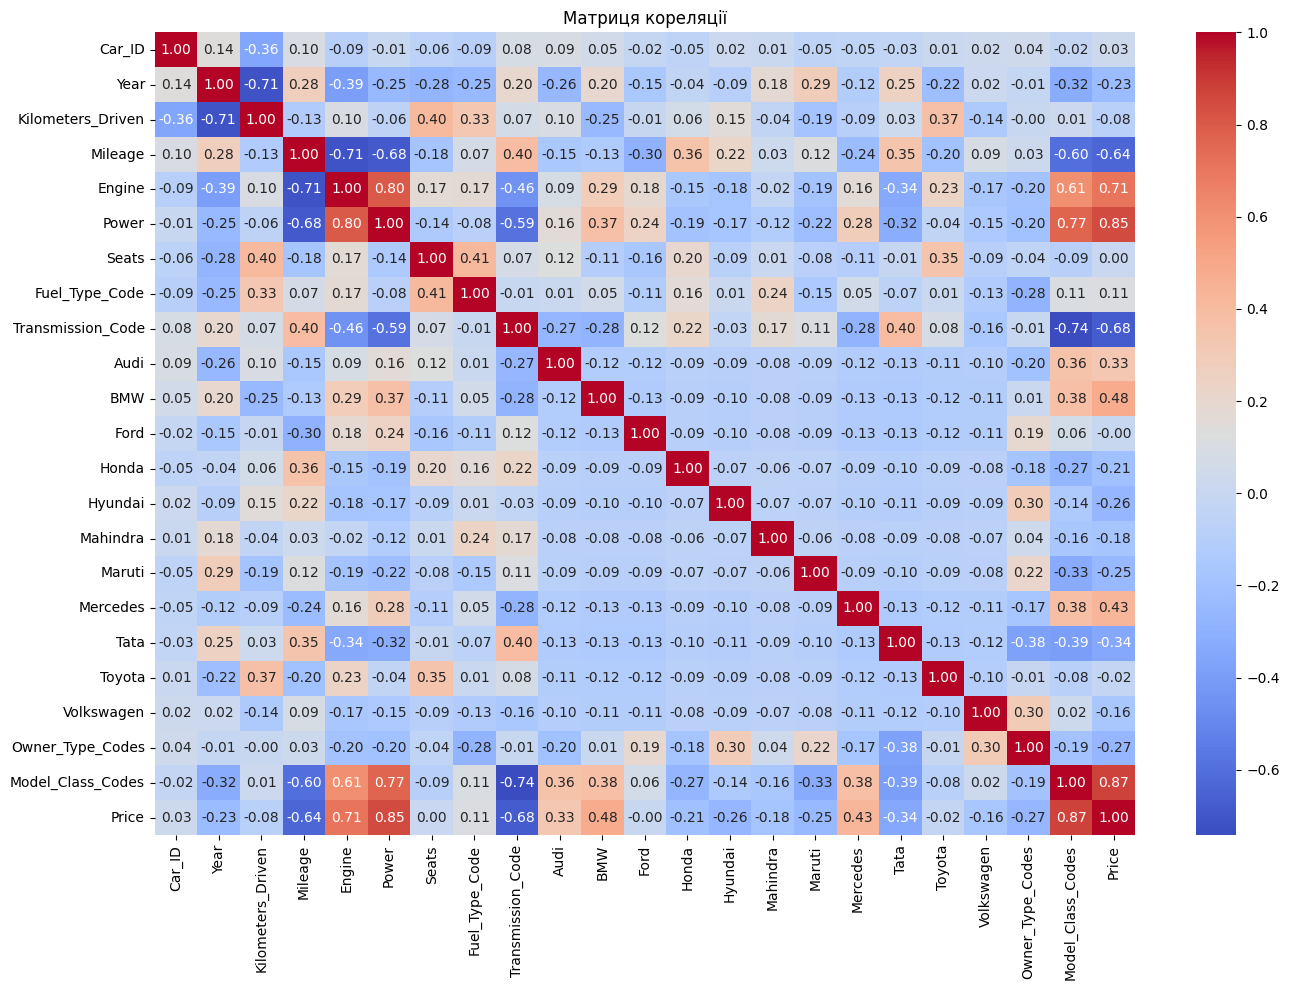

In [92]:
numeric_train = X_train.select_dtypes(include='number')
corr_df = pd.concat([numeric_train, y_train], axis=1)

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матриця кореляції')
plt.tight_layout()
plt.show()

З цільовою змінною Price на рівні > 0.5 за модулем корелюють:
- `Mileage` (негативна): чим більший пробіг на літр, тим нижча ціна
- `Engine` (позитивна): чим більший двигун, тим вища ціна
- `Power` (позитивна): чим більша потужність, тим вища ціна
- `Transmission_Code` (негативна): коробка автомат - 0, маеханічна - 1, отже з коробкою автомат ціна вище
- `Model_Class_Codes` (позитивна): чим вище клас авто, тим вища ціна


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [101]:
def train_model_show_rmse(inputs, targets):
    model = LinearRegression().fit(inputs, targets)
    predictions = model.predict(inputs)
    loss = root_mean_squared_error(targets, predictions)
    print('Loss:', loss)
    return model

In [95]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 83 to 75
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Car_ID             80 non-null     int64  
 1   Brand              80 non-null     object 
 2   Model              80 non-null     object 
 3   Year               80 non-null     int64  
 4   Kilometers_Driven  80 non-null     int64  
 5   Fuel_Type          80 non-null     object 
 6   Transmission       80 non-null     object 
 7   Owner_Type         80 non-null     object 
 8   Mileage            80 non-null     int64  
 9   Engine             80 non-null     int64  
 10  Power              80 non-null     int64  
 11  Seats              80 non-null     int64  
 12  price_class        80 non-null     object 
 13  Fuel_Type_Code     80 non-null     int64  
 14  Transmission_Code  80 non-null     int64  
 15  Audi               80 non-null     float64
 16  BMW                80 non-null  

In [97]:
X_train = X_train.select_dtypes(include='number')
X_test = X_test.select_dtypes(include='number')

In [102]:
model = train_model_show_rmse(X_train, y_train)

Loss: 208491.1856110287


In [116]:
y_train.std(), y_train.mean()

(1040405.2277717004, np.float64(1680000.0))

In [111]:
predictions_test  = model.predict(X_test)

In [113]:
test_loss  = root_mean_squared_error(y_test,  predictions_test)

In [114]:
print('Test RMSE: ', test_loss)

Test RMSE:  248264.01275503536


In [117]:
y_test.std(), y_test.mean()

(689965.6742033964, np.float64(1150000.0))

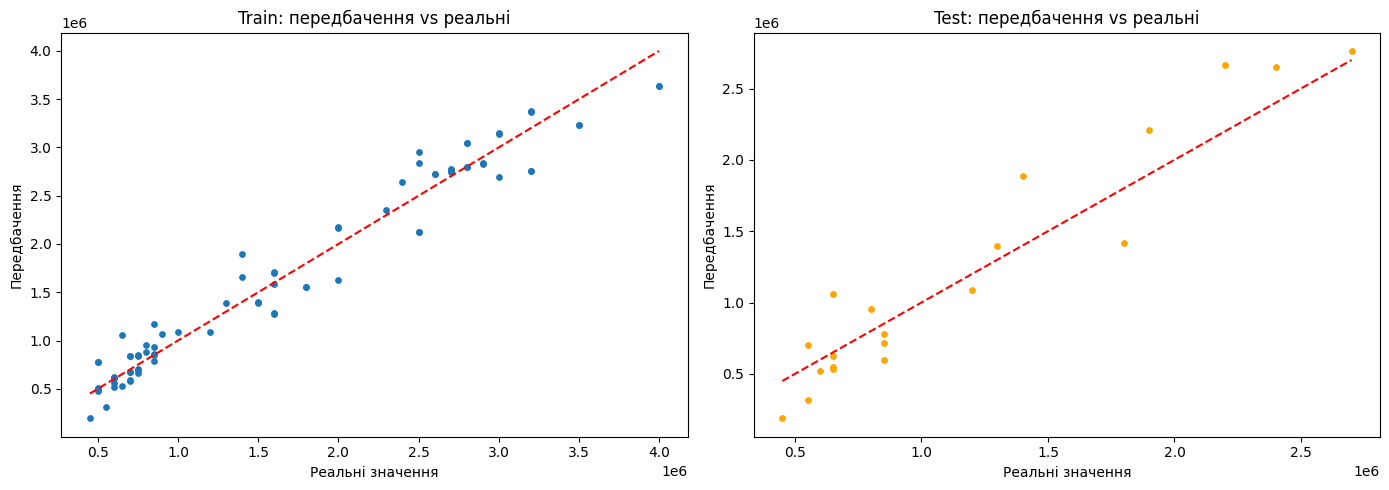

In [119]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_train, predictions_train, s=15)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Реальні значення')
ax1.set_ylabel('Передбачення')
ax1.set_title('Train: передбачення vs реальні')

ax2.scatter(y_test, predictions_test, s=15, color='orange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Реальні значення')
ax2.set_ylabel('Передбачення')
ax2.set_title('Test: передбачення vs реальні')

plt.tight_layout()
plt.show()

**Висновок:**

- Точки на обох графіках розташовані близько до лінії передбачення, що каже про хорошу якість моделі - вона відображає загальну залежність між ознаками і цільовою змінною як на тренувальних, так і на тестових даних.
- На тестовому наборі розкид точок навколо лінії помітно більший за тренувальний, особливо зі збільшенням ціни, (в більшості, передбачення занижені відносно реальних значень).


**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [120]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [121]:
model_scaled = train_model_show_rmse(X_train_scaled, y_train)

Loss: 208491.18561102857


In [123]:
feature_names = X_train.columns.tolist()

weights_df = pd.DataFrame({
    'feature': feature_names,
    'weight':  model_scaled.coef_
})
weights_df = weights_df.sort_values('weight', ascending=False, key=abs)
weights_df

,feature,weight
5,Power,476440.211538
16,Mercedes,196600.057043
10,BMW,192052.445119
9,Audi,190690.204804
7,Fuel_Type_Code,174792.577390
13,Hyundai,-146720.127008
14,Mahindra,-133556.659632
11,Ford,-119670.484814
3,Mileage,-119398.133823
2,Kilometers_Driven,-103084.427686


- `Power` (позитивний): чим більша потужність авто, тим вища ціна.
- `Mercedes`, `BMW`, `Audi` (позитивний): автомобілі відомих брендів більш статусні, тому коштують дорожче.
- `Fuel_Type_Code` (позитивний): автомобілі на бензині коштують дорожче.
- `Hyundai`, `Mahindra`, `Ford` (негативний): менш відомі марки автомобілів серед високого цінового сегменту.
- `Mileage` (негативний): чим більше споживання палива на кілометр, тим дешевша машина.
- `Kilometers_Driven` (негативний): чим більший пробіг, тим менше вартує авто.
  

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [124]:
X_train_scaled_sm = sm.add_constant(X_train_scaled)

ols_model = sm.OLS(y_train, X_train_scaled_sm)
results = ols_model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     65.15
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.03e-32
Time:                        18:44:52   Log-Likelihood:                -1093.3
No. Observations:                  80   AIC:                             2231.
Df Residuals:                      58   BIC:                             2283.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   2.74e+04     61.367      0.0

In [129]:
pvalues = results.pvalues[1:]
pvalues.index = feature_names

significant_005 = pvalues[pvalues < 0.05].sort_values()
significant_005

,0
Power,9.240850e-08
Mercedes,3.461122e-07
Audi,5.728490e-07
BMW,1.500257e-06
Hyundai,6.395719e-06
Mahindra,5.272875e-05
Fuel_Type_Code,4.028484e-04
Ford,7.787685e-04
Volkswagen,2.054616e-03
Maruti,3.335040e-03


In [130]:
significant_cols = significant_005.index.tolist()

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [131]:
significant_cols

['Power',
 'Mercedes',
 'Audi',
 'BMW',
 'Hyundai',
 'Mahindra',
 'Fuel_Type_Code',
 'Ford',
 'Volkswagen',
 'Maruti',
 'Mileage']

In [139]:
col_indices = [feature_names.index(col) for col in significant_cols]

In [133]:
col_indices

[5, 16, 9, 10, 13, 14, 7, 11, 19, 15, 3]

In [134]:
X_train_sig = X_train_scaled[:, col_indices]
X_test_sig  = X_test_scaled[:, col_indices]

In [135]:
X_train_sig_sm = sm.add_constant(X_train_sig)

ols_sig = sm.OLS(y_train, X_train_sig_sm)
results_sig = ols_sig.fit()
print(results_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     105.6
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.91e-38
Time:                        19:28:25   Log-Likelihood:                -1105.6
No. Observations:                  80   AIC:                             2235.
Df Residuals:                      68   BIC:                             2264.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   2.95e+04     56.990      0.0

- R-squared після тренуванні моделі лише на стат. значущих ознаках трохи зменшилась, але це можна пояснити меншою кількістю ознак, на яких тренується модель.
- Проте друга модель також має менший показник Adj. R-squared, що означає, що наша перша модель мала ознаки, які покращують якість передбачення, і не була оштрафована.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [137]:
pvalues = results.pvalues[1:]
pvalues.index = feature_names

significant_025 = pvalues[pvalues < 0.25].sort_values()
significant_025

,0
Power,9.240850e-08
Mercedes,3.461122e-07
Audi,5.728490e-07
BMW,1.500257e-06
Hyundai,6.395719e-06
Mahindra,5.272875e-05
Fuel_Type_Code,4.028484e-04
Ford,7.787685e-04
Volkswagen,2.054616e-03
Maruti,3.335040e-03


In [138]:
significant_cols_2 = significant_025.index.tolist()

In [140]:
col_indices_2 = [feature_names.index(col) for col in significant_cols_2]

In [141]:
X_train_sig_2 = X_train_scaled[:, col_indices_2]
X_test_sig_2  = X_test_scaled[:, col_indices_2]

In [142]:
X_train_sig_sm_2 = sm.add_constant(X_train_sig_2)

ols_sig_2 = sm.OLS(y_train, X_train_sig_sm_2)
results_sig_2 = ols_sig_2.fit()
print(results_sig_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        19:50:29   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   2.65e+04     63.341      0.0

**Висновок:**
- Серед трьох моделей найкраще значення Adj. R-squared у Моделі 3 = 0.948
- Найкраще значення R-squared у Моделі 1 = 0.959, хоча це пояснюється найбільшою кількістю ознак використаних для навчання моделі
- p-value для усіх ознак Моделі 3 < 0,05, отже всі є стат. значущими

Тому серед трьох моделей найкраща Модель 3, яка є оптимальною за кількістю використаних ознак для навчання та точністю передбачення.